
Dataset size = 1000
Skip List access: 4.278 ± 0.771 ms
B+ Tree access  : 0.812 ± 0.177 ms
Skip List mem   : 0.087 MB
B+ Tree mem     : 0.034 MB

Dataset size = 10000
Skip List access: 52.066 ± 7.340 ms
B+ Tree access  : 10.457 ± 1.684 ms
Skip List mem   : 0.274 MB
B+ Tree mem     : 0.128 MB

Dataset size = 100000
Skip List access: 566.344 ± 46.847 ms
B+ Tree access  : 117.891 ± 18.104 ms
Skip List mem   : 0.302 MB
B+ Tree mem     : 0.154 MB


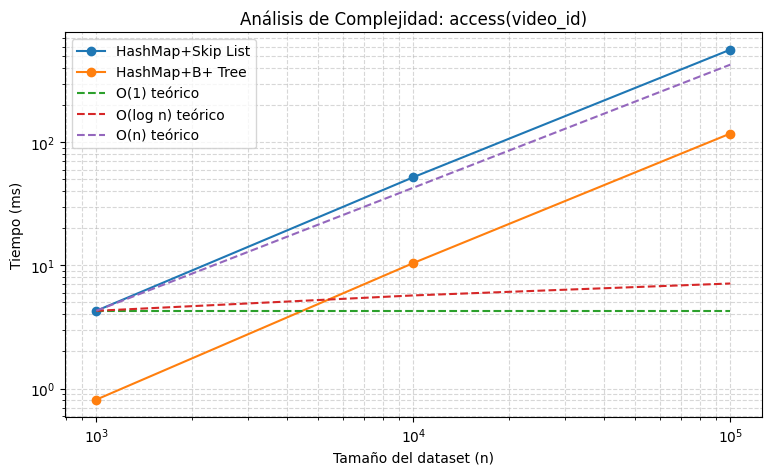

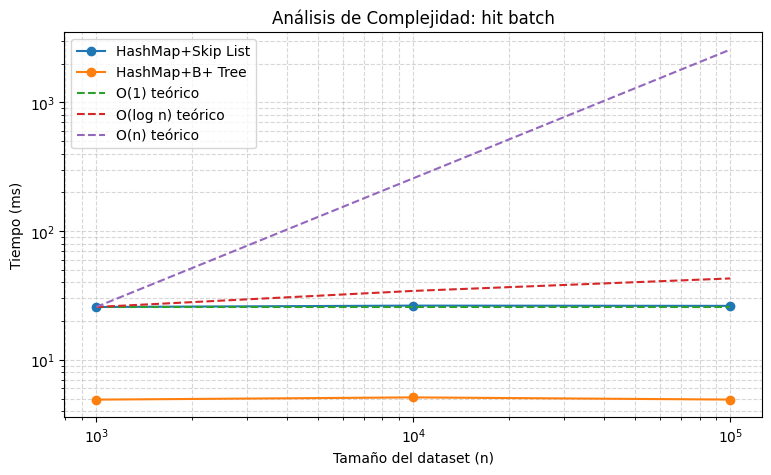

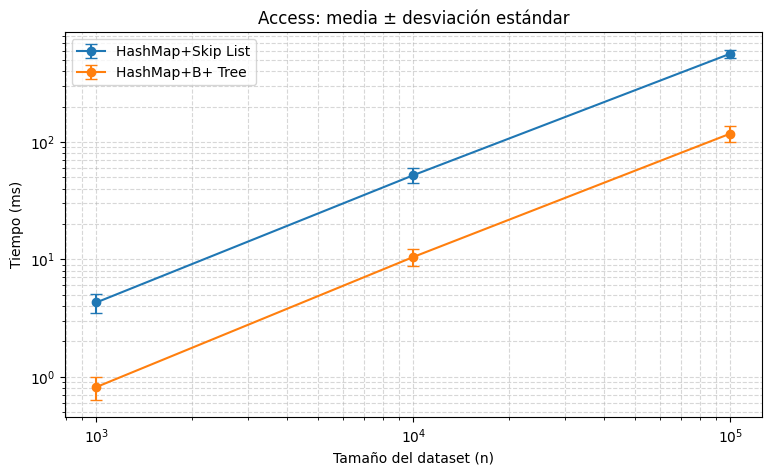

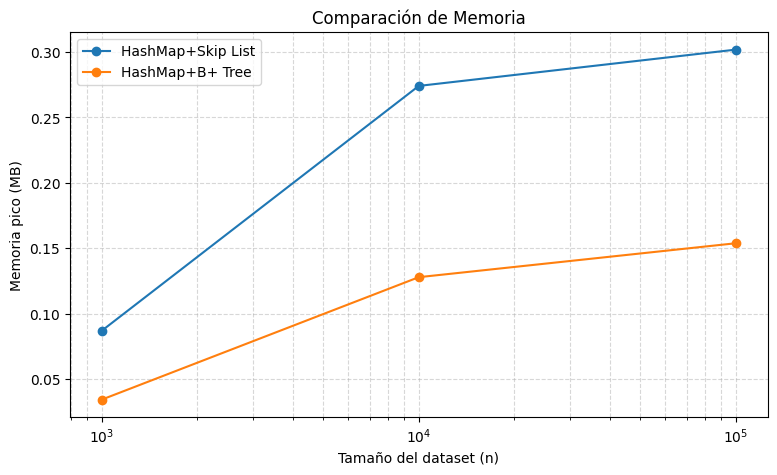

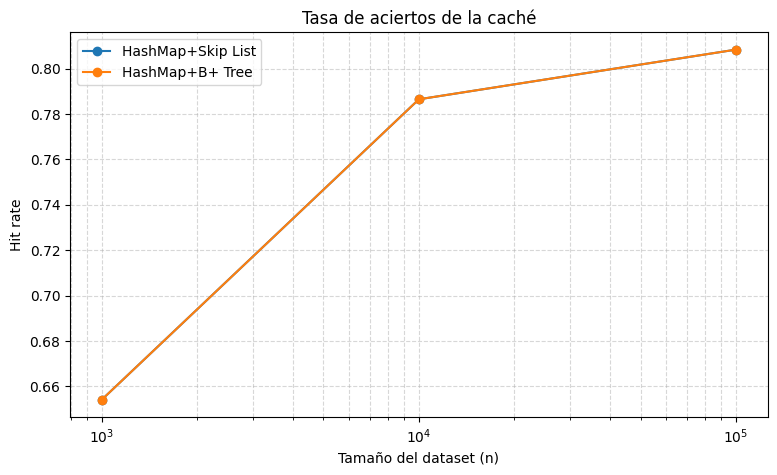


         n |    Skip access |  B+Tree access |       Skip hit |     B+Tree hit |    Skip rate |  B+Tree rate |     Skip Mem |   B+Tree Mem
      1000 |          4.278 |          0.812 |         25.720 |          4.903 |       0.6542 |       0.6542 |        0.087 |        0.034
     10000 |         52.066 |         10.457 |         26.368 |          5.102 |       0.7865 |       0.7865 |        0.274 |        0.128
    100000 |        566.344 |        117.891 |         26.240 |          4.908 |       0.8083 |       0.8083 |        0.302 |        0.154


In [2]:
# =========================================================
# EXPERIMENTACIÓN Y ANÁLISIS
# Caché de Contenido Inteligente (LRU)
# Comparación:
#   1) HashMap + B+ Tree
#   2) HashMap + Skip List
# =========================================================

import random
import time
import math
import statistics
import tracemalloc
import bisect
import matplotlib.pyplot as plt


# =========================================================
# 1. GENERADOR DE STREAM DE ACCESOS
# =========================================================
def generate_access_stream(n, num_videos=50000, skew=1.2, seed=42):
    random.seed(seed)
    video_ids = [f"video_{i}" for i in range(num_videos)]
    weights = [1 / ((i + 1) ** skew) for i in range(num_videos)]
    total = sum(weights)
    probs = [w / total for w in weights]
    return random.choices(video_ids, weights=probs, k=n)


# =========================================================
# 2. HASHMAP + SKIP LIST (LRU)
# =========================================================
class SkipListNode:
    def __init__(self, key=None, value=None, level=1):
        self.key = key
        self.value = value
        self.forward = [None] * level


class SkipList:
    def __init__(self, max_level=16, p=0.5):
        self.max_level = max_level
        self.p = p
        self.level = 1
        self.header = SkipListNode(level=max_level)

    def random_level(self):
        lvl = 1
        while random.random() < self.p and lvl < self.max_level:
            lvl += 1
        return lvl

    def insert(self, key, value):
        update = [None] * self.max_level
        current = self.header

        for i in reversed(range(self.level)):
            while current.forward[i] is not None and current.forward[i].key < key:
                current = current.forward[i]
            update[i] = current

        lvl = self.random_level()

        if lvl > self.level:
            for i in range(self.level, lvl):
                update[i] = self.header
            self.level = lvl

        node = SkipListNode(key=key, value=value, level=lvl)

        for i in range(lvl):
            node.forward[i] = update[i].forward[i]
            update[i].forward[i] = node

    def delete(self, key):
        update = [None] * self.max_level
        current = self.header

        for i in reversed(range(self.level)):
            while current.forward[i] is not None and current.forward[i].key < key:
                current = current.forward[i]
            update[i] = current

        target = current.forward[0]
        if target is not None and target.key == key:
            for i in range(self.level):
                if update[i].forward[i] != target:
                    break
                update[i].forward[i] = target.forward[i]

            while self.level > 1 and self.header.forward[self.level - 1] is None:
                self.level -= 1
            return True
        return False

    def min_item(self):
        node = self.header.forward[0]
        if node is None:
            return None
        return node.key, node.value


class HashMapSkipListLRUCache:
    def __init__(self, capacity=1000):
        self.capacity = capacity
        self.skip = SkipList()
        self.map = {}              # video_id -> timestamp
        self.time = 0
        self.hits = 0
        self.misses = 0

    def _evict_if_needed(self):
        if len(self.map) > self.capacity:
            item = self.skip.min_item()
            if item is not None:
                old_ts, vid = item
                self.skip.delete(old_ts)
                if vid in self.map and self.map[vid] == old_ts:
                    del self.map[vid]

    def access(self, video_id):
        self.time += 1
        new_ts = self.time

        if video_id in self.map:
            self.hits += 1
            old_ts = self.map[video_id]
            self.skip.delete(old_ts)
        else:
            self.misses += 1

        self.map[video_id] = new_ts
        self.skip.insert(new_ts, video_id)

        if len(self.map) > self.capacity:
            self._evict_if_needed()

    def stats(self):
        total = self.hits + self.misses
        return {
            "hits": self.hits,
            "misses": self.misses,
            "hit_rate": self.hits / total if total > 0 else 0,
            "size": len(self.map)
        }


# =========================================================
# 3. HASHMAP + B+ TREE (LRU)
# =========================================================
# Implementación práctica simplificada:
# índice ordenado por timestamp usando listas ordenadas + bisect.
# Sirve para experimentar con una estructura ordenada tipo B+ Tree.

class SimpleBPlusTree:
    def __init__(self):
        self.keys = []
        self.values = []

    def insert(self, key, value):
        idx = bisect.bisect_left(self.keys, key)
        self.keys.insert(idx, key)
        self.values.insert(idx, value)

    def delete(self, key):
        idx = bisect.bisect_left(self.keys, key)
        if idx < len(self.keys) and self.keys[idx] == key:
            self.keys.pop(idx)
            self.values.pop(idx)
            return True
        return False

    def min_item(self):
        if not self.keys:
            return None
        return self.keys[0], self.values[0]


class HashMapBPlusTreeLRUCache:
    def __init__(self, capacity=1000):
        self.capacity = capacity
        self.tree = SimpleBPlusTree()
        self.map = {}              # video_id -> timestamp
        self.time = 0
        self.hits = 0
        self.misses = 0

    def _evict_if_needed(self):
        if len(self.map) > self.capacity:
            item = self.tree.min_item()
            if item is not None:
                old_ts, vid = item
                self.tree.delete(old_ts)
                if vid in self.map and self.map[vid] == old_ts:
                    del self.map[vid]

    def access(self, video_id):
        self.time += 1
        new_ts = self.time

        if video_id in self.map:
            self.hits += 1
            old_ts = self.map[video_id]
            self.tree.delete(old_ts)
        else:
            self.misses += 1

        self.map[video_id] = new_ts
        self.tree.insert(new_ts, video_id)

        if len(self.map) > self.capacity:
            self._evict_if_needed()

    def stats(self):
        total = self.hits + self.misses
        return {
            "hits": self.hits,
            "misses": self.misses,
            "hit_rate": self.hits / total if total > 0 else 0,
            "size": len(self.map)
        }


# =========================================================
# 4. BENCHMARK DE ACCESS
# =========================================================
def benchmark_access(cache_class, stream, capacity=1000):
    cache = cache_class(capacity=capacity)

    t0 = time.perf_counter()
    for vid in stream:
        cache.access(vid)
    t1 = time.perf_counter()

    total_ms = (t1 - t0) * 1000
    stats = cache.stats()
    return cache, total_ms, stats


# =========================================================
# 5. BENCHMARK DE HIT BATCH
# =========================================================
def benchmark_hits(cache_class, warmup_stream, hit_queries, capacity=1000):
    cache = cache_class(capacity=capacity)

    for vid in warmup_stream:
        cache.access(vid)

    t0 = time.perf_counter()
    for vid in hit_queries:
        cache.access(vid)
    t1 = time.perf_counter()

    return (t1 - t0) * 1000


# =========================================================
# 6. MEMORIA
# =========================================================
def memory_test(cache_class, stream, capacity=1000):
    tracemalloc.start()
    cache = cache_class(capacity=capacity)
    for vid in stream:
        cache.access(vid)
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return current / 10**6, peak / 10**6


# =========================================================
# 7. CURVAS TEÓRICAS
# =========================================================
def scale_curve(reference_times, base_curve):
    factor = reference_times[0] / base_curve[0]
    return [factor * x for x in base_curve]

def make_theoretical_curves(sizes, reference_times):
    O1 = scale_curve(reference_times, [1 for _ in sizes])
    Ologn = scale_curve(reference_times, [math.log2(n) for n in sizes])
    On = scale_curve(reference_times, [n for n in sizes])
    Onlogn = scale_curve(reference_times, [n * math.log2(n) for n in sizes])
    return O1, Ologn, On, Onlogn


# =========================================================
# 8. EXPERIMENTO COMPLETO
# =========================================================
def run_full_experiment(sizes, repeats=100, capacity=1000, seed_base=1000):
    results = {
        "skip_access_mean": [], "skip_access_std": [],
        "skip_hit_mean": [], "skip_hit_std": [],
        "skip_hit_rate": [], "skip_mem_peak": [],

        "bpt_access_mean": [], "bpt_access_std": [],
        "bpt_hit_mean": [], "bpt_hit_std": [],
        "bpt_hit_rate": [], "bpt_mem_peak": [],
    }

    for idx, n in enumerate(sizes):
        print(f"\n==============================")
        print(f"Dataset size = {n}")
        print(f"==============================")

        skip_access_times, skip_hit_times, skip_hit_rates = [], [], []
        bpt_access_times, bpt_hit_times, bpt_hit_rates = [], [], []

        # memoria una vez por tamaño
        mem_stream = generate_access_stream(n, seed=seed_base + idx)
        _, skip_peak = memory_test(HashMapSkipListLRUCache, mem_stream, capacity=capacity)
        _, bpt_peak = memory_test(HashMapBPlusTreeLRUCache, mem_stream, capacity=capacity)

        results["skip_mem_peak"].append(skip_peak)
        results["bpt_mem_peak"].append(bpt_peak)

        for r in range(repeats):
            seed = seed_base + idx * 1000 + r
            stream = generate_access_stream(n, seed=seed)

            # access total
            _, skip_ms, skip_stats = benchmark_access(HashMapSkipListLRUCache, stream, capacity=capacity)
            _, bpt_ms, bpt_stats = benchmark_access(HashMapBPlusTreeLRUCache, stream, capacity=capacity)

            skip_access_times.append(skip_ms)
            bpt_access_times.append(bpt_ms)

            skip_hit_rates.append(skip_stats["hit_rate"])
            bpt_hit_rates.append(bpt_stats["hit_rate"])

            # hit batch
            warmup = stream[:max(capacity * 2, 2000)]
            candidate_hits = warmup[-capacity:] if len(warmup) >= capacity else warmup
            hit_queries = [random.choice(candidate_hits) for _ in range(5000)]

            skip_hit_times.append(
                benchmark_hits(HashMapSkipListLRUCache, warmup, hit_queries, capacity=capacity)
            )
            bpt_hit_times.append(
                benchmark_hits(HashMapBPlusTreeLRUCache, warmup, hit_queries, capacity=capacity)
            )

        results["skip_access_mean"].append(statistics.mean(skip_access_times))
        results["skip_access_std"].append(statistics.stdev(skip_access_times))
        results["skip_hit_mean"].append(statistics.mean(skip_hit_times))
        results["skip_hit_std"].append(statistics.stdev(skip_hit_times))
        results["skip_hit_rate"].append(statistics.mean(skip_hit_rates))

        results["bpt_access_mean"].append(statistics.mean(bpt_access_times))
        results["bpt_access_std"].append(statistics.stdev(bpt_access_times))
        results["bpt_hit_mean"].append(statistics.mean(bpt_hit_times))
        results["bpt_hit_std"].append(statistics.stdev(bpt_hit_times))
        results["bpt_hit_rate"].append(statistics.mean(bpt_hit_rates))

        print(f"Skip List access: {results['skip_access_mean'][-1]:.3f} ± {results['skip_access_std'][-1]:.3f} ms")
        print(f"B+ Tree access  : {results['bpt_access_mean'][-1]:.3f} ± {results['bpt_access_std'][-1]:.3f} ms")
        print(f"Skip List mem   : {results['skip_mem_peak'][-1]:.3f} MB")
        print(f"B+ Tree mem     : {results['bpt_mem_peak'][-1]:.3f} MB")

    return results


# =========================================================
# 9. PARÁMETROS
# =========================================================
# Para Colab:
sizes = [10**3, 10**4, 10**5]

# Si tu entorno aguanta:
# sizes = [10**3, 10**4, 10**5, 10**6, 10**7]

repeats = 100
capacity = 1000


# =========================================================
# 10. EJECUTAR
# =========================================================
results = run_full_experiment(sizes=sizes, repeats=repeats, capacity=capacity)


# =========================================================
# 11. GRÁFICO LOG-LOG: ACCESS TOTAL
# =========================================================
skip_access = results["skip_access_mean"]
bpt_access = results["bpt_access_mean"]

O1, Ologn, On, Onlogn = make_theoretical_curves(sizes, skip_access)

plt.figure(figsize=(9, 5))
plt.loglog(sizes, skip_access, 'o-', label='HashMap+Skip List')
plt.loglog(sizes, bpt_access, 'o-', label='HashMap+B+ Tree')
plt.loglog(sizes, O1, '--', label='O(1) teórico')
plt.loglog(sizes, Ologn, '--', label='O(log n) teórico')
plt.loglog(sizes, On, '--', label='O(n) teórico')
plt.xlabel('Tamaño del dataset (n)')
plt.ylabel('Tiempo (ms)')
plt.legend()
plt.title('Análisis de Complejidad: access(video_id)')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()


# =========================================================
# 12. GRÁFICO LOG-LOG: HIT BATCH
# =========================================================
skip_hit = results["skip_hit_mean"]
bpt_hit = results["bpt_hit_mean"]

O1, Ologn, On, Onlogn = make_theoretical_curves(sizes, skip_hit)

plt.figure(figsize=(9, 5))
plt.loglog(sizes, skip_hit, 'o-', label='HashMap+Skip List')
plt.loglog(sizes, bpt_hit, 'o-', label='HashMap+B+ Tree')
plt.loglog(sizes, O1, '--', label='O(1) teórico')
plt.loglog(sizes, Ologn, '--', label='O(log n) teórico')
plt.loglog(sizes, On, '--', label='O(n) teórico')
plt.xlabel('Tamaño del dataset (n)')
plt.ylabel('Tiempo (ms)')
plt.legend()
plt.title('Análisis de Complejidad: hit batch')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()


# =========================================================
# 13. BARRAS DE ERROR
# =========================================================
plt.figure(figsize=(9, 5))
plt.errorbar(sizes, results["skip_access_mean"], yerr=results["skip_access_std"], fmt='o-', capsize=4, label='HashMap+Skip List')
plt.errorbar(sizes, results["bpt_access_mean"], yerr=results["bpt_access_std"], fmt='o-', capsize=4, label='HashMap+B+ Tree')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Tamaño del dataset (n)')
plt.ylabel('Tiempo (ms)')
plt.title('Access: media ± desviación estándar')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()


# =========================================================
# 14. MEMORIA
# =========================================================
plt.figure(figsize=(9, 5))
plt.plot(sizes, results["skip_mem_peak"], 'o-', label='HashMap+Skip List')
plt.plot(sizes, results["bpt_mem_peak"], 'o-', label='HashMap+B+ Tree')
plt.xscale('log')
plt.xlabel('Tamaño del dataset (n)')
plt.ylabel('Memoria pico (MB)')
plt.title('Comparación de Memoria')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()


# =========================================================
# 15. HIT RATE
# =========================================================
plt.figure(figsize=(9, 5))
plt.plot(sizes, results["skip_hit_rate"], 'o-', label='HashMap+Skip List')
plt.plot(sizes, results["bpt_hit_rate"], 'o-', label='HashMap+B+ Tree')
plt.xscale('log')
plt.xlabel('Tamaño del dataset (n)')
plt.ylabel('Hit rate')
plt.title('Tasa de aciertos de la caché')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()


# =========================================================
# 16. RESUMEN FINAL
# =========================================================
print("\n" + "=" * 110)
print(f"{'n':>10} | {'Skip access':>14} | {'B+Tree access':>14} | {'Skip hit':>14} | {'B+Tree hit':>14} | {'Skip rate':>12} | {'B+Tree rate':>12} | {'Skip Mem':>12} | {'B+Tree Mem':>12}")
print("=" * 110)

for i, n in enumerate(sizes):
    print(
        f"{n:>10} | "
        f"{results['skip_access_mean'][i]:>14.3f} | "
        f"{results['bpt_access_mean'][i]:>14.3f} | "
        f"{results['skip_hit_mean'][i]:>14.3f} | "
        f"{results['bpt_hit_mean'][i]:>14.3f} | "
        f"{results['skip_hit_rate'][i]:>12.4f} | "
        f"{results['bpt_hit_rate'][i]:>12.4f} | "
        f"{results['skip_mem_peak'][i]:>12.3f} | "
        f"{results['bpt_mem_peak'][i]:>12.3f}"
    )